In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv


Đã tìm thấy file tại đường dẫn: /kaggle/input/datasets/fatemehmehrparvar/obesity-levels/ObesityDataSet_raw_and_data_sinthetic.csv

=> Dữ liệu 5 dòng đầu tiên:


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


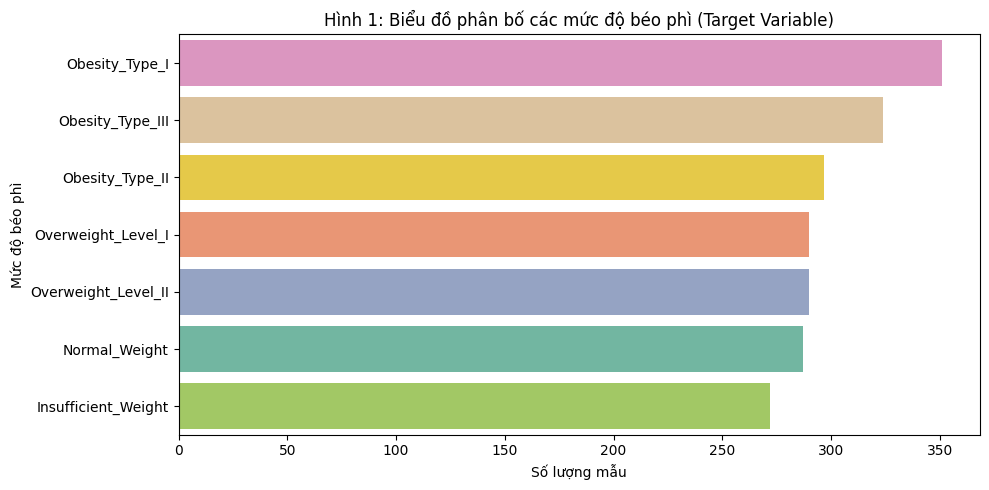


=> [Section 1 & 2]: Đã hoàn thành EDA và tiền xử lý tổng hợp dữ liệu sạch, không còn cảnh báo!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tự động lục tìm file .csv trong thư mục input
file_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            break

print("Đã tìm thấy file tại đường dẫn:", file_path)

# 2. Đọc file dữ liệu từ đường dẫn vừa tìm được
df = pd.read_csv(file_path)

# 3. In ra 5 dòng đầu tiên để xem hình thù dữ liệu
print("\n=> Dữ liệu 5 dòng đầu tiên:")
display(df.head())

# --- SECTION 1: EDA - Vẽ biểu đồ phân bố cho biến mục tiêu NObeyesdad ---
plt.figure(figsize=(10, 5))
# ĐÃ SỬA: Thêm hue='NObeyesdad' và legend=False để xóa sạch dòng cảnh báo màu hồng
sns.countplot(y='NObeyesdad', data=df, order=df['NObeyesdad'].value_counts().index, palette='Set2', hue='NObeyesdad', legend=False)
plt.title('Hình 1: Biểu đồ phân bố các mức độ béo phì (Target Variable)')
plt.xlabel('Số lượng mẫu')
plt.ylabel('Mức độ béo phì')
plt.tight_layout()
plt.show()

# --- SECTION 2: DATA PREPROCESSING ---
# 4. Tách biến mục tiêu (y) và biến đầu vào (X)
X = df.drop(['NObeyesdad'], axis=1)
y = df['NObeyesdad']

# 5. Danh sách các cột định tính (chữ) và định lượng (số)
cat_columns = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
num_columns = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# 6. Biến đổi biến định tính thành số bằng OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[cat_columns])

# 7. Đảm bảo biến định lượng là kiểu số thực (float)
X_num = df[num_columns].values.astype(float)

# 8. Ghép tất cả lại thành một ma trận hoàn chỉnh
X_selected_matrix = np.hstack([X_num, X_cat])

# 9. Mã hóa chuỗi văn bản của biến mục tiêu NObeyesdad sang dạng số
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 10. Thiết lập chia tập dữ liệu bằng StratifiedKFold (5-Fold) để tránh rò rỉ dữ liệu
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=> [Section 1 & 2]: Đã hoàn thành EDA và tiền xử lý tổng hợp dữ liệu sạch, không còn cảnh báo!")

In [3]:
# =========================================================================
# SECTION 3: MODEL SELECTION 1 (TINH CHỈNH SIÊU THAM SỐ CÁC MÔ HÌNH)
# =========================================================================
print("--- [Section 3]: BẮT ĐẦU QUÁ TRÌNH QUÉT THAM SỐ QUA GRIDSEARCHCV ---")

# 11.1 Tinh chỉnh siêu tham số cho mô hình K-Nearest Neighbors (KNN)
print("Đang quét mô hình KNN...")
knn_param = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param, cv=skf, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> KNN Tốt Nhất: {knn_grid.best_params_} | Đạt Accuracy: {knn_grid.best_score_:.4f}\n")

# 11.2 Tinh chỉnh siêu tham số cho mô hình Decision Tree (Cây quyết định)
print("Đang quét mô hình Decision Tree...")
tree_param = {'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, 20]}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_param, cv=skf, scoring='accuracy', n_jobs=-1)
tree_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> Decision Tree Tốt Nhất: {tree_grid.best_params_} | Đạt Accuracy: {tree_grid.best_score_:.4f}\n")

# 11.3 Tinh chỉnh siêu tham số cho mô hình Random Forest (Rừng ngẫu nhiên)
print("Đang quét mô hình Random Forest...")
rf_param = {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param, cv=skf, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> Random Forest Tốt Nhất: {rf_grid.best_params_} | Đạt Accuracy: {rf_grid.best_score_:.4f}\n")

--- [Section 3]: BẮT ĐẦU QUÁ TRÌNH QUÉT THAM SỐ QUA GRIDSEARCHCV ---
Đang quét mô hình KNN...
   -> KNN Tốt Nhất: {'n_neighbors': 3, 'weights': 'distance'} | Đạt Accuracy: 0.8972

Đang quét mô hình Decision Tree...
   -> Decision Tree Tốt Nhất: {'criterion': 'entropy', 'max_depth': None} | Đạt Accuracy: 0.9536

Đang quét mô hình Random Forest...
   -> Random Forest Tốt Nhất: {'max_depth': None, 'n_estimators': 150} | Đạt Accuracy: 0.9413



--- [Section 4]: TIẾN HÀNH XUẤT ĐỒ THỊ THỰC NGHIỆM ---


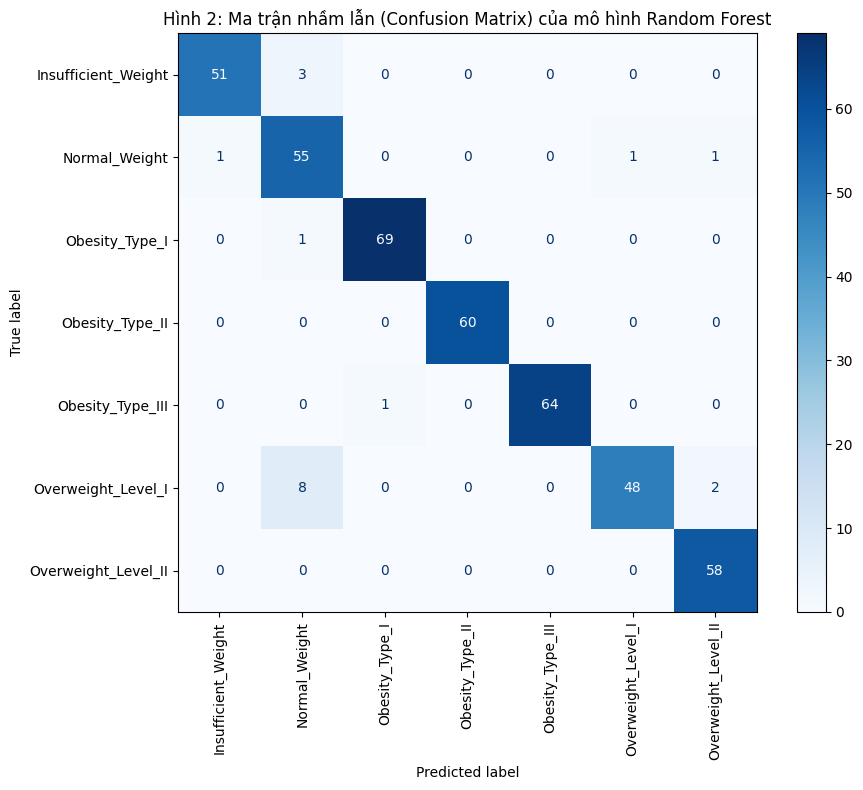

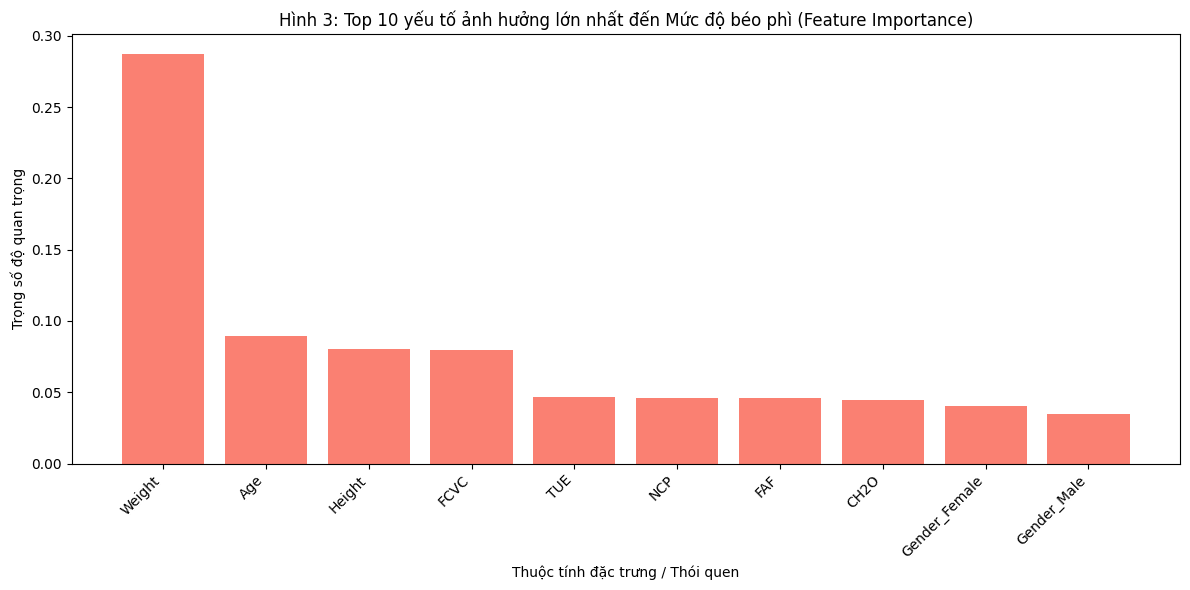

In [4]:
# =========================================================================
# SECTION 4: EVALUATION (ĐÁNH GIÁ VÀ XUẤT BIỂU ĐỒ BÁO CÁO ĐỒ ÁN)
# =========================================================================
print("--- [Section 4]: TIẾN HÀNH XUẤT ĐỒ THỊ THỰC NGHIỆM ---")

# Lấy estimator tốt nhất từ kết quả GridSearchCV của Random Forest
best_rf = rf_grid.best_estimator_

# Trích tách thử một fold thực nghiệm độc lập để lấy dữ liệu Test vẽ đồ thị minh họa
for train_idx, test_idx in skf.split(X_selected_matrix, y_encoded):
    X_train, X_test = X_selected_matrix[train_idx], X_selected_matrix[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    break

# Huấn luyện nhanh trên fold này để lấy kết quả vẽ ma trận nhầm lẫn
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

# 12.1 Vẽ Ma trận nhầm lẫn (Confusion Matrix) phục vụ báo cáo
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("Hình 2: Ma trận nhầm lẫn (Confusion Matrix) của mô hình Random Forest")
plt.tight_layout()
plt.show()

# 12.2 Trích xuất Feature Importance để tìm ra thói quen/thể trạng ảnh hưởng nhất
encoded_cat_names = encoder.get_feature_names_out(cat_columns).tolist()
all_feature_names = num_columns + encoded_cat_names

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Tiến hành vẽ biểu đồ cột Top 10 đặc trưng hàng đầu
top_k = 10
plt.figure(figsize=(12, 6))
plt.title("Hình 3: Top 10 yếu tố ảnh hưởng lớn nhất đến Mức độ béo phì (Feature Importance)")
plt.bar(range(top_k), importances[indices[:top_k]], align="center", color='salmon')
plt.xticks(range(top_k), [all_feature_names[i] for i in indices[:top_k]], rotation=45, ha='right')
plt.xlabel("Thuộc tính đặc trưng / Thói quen")
plt.ylabel("Trọng số độ quan trọng")
plt.tight_layout()
plt.show()

In [5]:
# =========================================================================
# SECTION 3 (PART 2): HUẤN LUYỆN VÀ TINH CHỈNH SÂU (DEEP FINE-TUNING)
# Được thực hiện bởi Vũ Thiên Sinh
# =========================================================================
print("--- [Section 3 - Part 2]: BẮT ĐẦU QUÉT CẠN THAM SỐ SÂU CHO SVM & MLP ---")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Thiết lập các Pipeline chuẩn hóa độc lập CHỐNG DATA LEAKAGE cho SVM và MLP
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)) # Bật xác suất để phục vụ vẽ ROC
])

pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1500)) # Tăng max_iter lên 1500 để đảm bảo hội tụ hoàn toàn
])

# -------------------------------------------------------------------------
# 11.4 Huấn luyện Baseline Naive Bayes
# -------------------------------------------------------------------------
print("\nĐang quét mô hình Naive Bayes...")
nb_grid = GridSearchCV(GaussianNB(), param_grid={}, cv=skf, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> Naive Bayes Tốt Nhất | Đạt Accuracy: {nb_grid.best_score_:.4f}")

# -------------------------------------------------------------------------
# 11.5 DEEP FINE-TUNING CHO SVM (Quét cạn cả không gian phẳng và cong)
# Tổng cộng quét: 6 giá trị C x 2 Kernels x 5 Gamma x 5 Folds = 300 fits
# -------------------------------------------------------------------------
print("\nĐang tiến hành quét cạn không gian siêu tham số của SVM...")
svm_param_deep = {
    'svm__C': [0.01, 0.1, 1, 10, 50, 100],               # Khảo sát biên độ phạt lỗi từ lỏng đến gắt
    'svm__kernel': ['linear', 'rbf'],                    # Khảo sát không gian phẳng vs không gian cong RBF
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]    # Tầm ảnh hưởng của ranh giới phi tuyến
}
svm_grid = GridSearchCV(pipe_svm, svm_param_deep, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> SVM Tối Ưu Nhất: {svm_grid.best_params_}")
print(f"   -> Đạt Accuracy (CV): {svm_grid.best_score_:.4f}")

# -------------------------------------------------------------------------
# 11.6 DEEP FINE-TUNING CHO NEURAL NETWORK (MLP)
# Khảo sát cấu trúc tầng ẩn sâu hơn, chống Overfitting bằng alpha và Early Stopping
# -------------------------------------------------------------------------
print("\nĐang tiến hành quét sâu cấu trúc Mạng Nơ-ron nhân tạo (MLP)...")
mlp_param_deep = {
    'mlp__hidden_layer_sizes': [(100,), (50, 50), (100, 50), (50, 50, 50), (128, 64)], # Từ mạng nông đến cấu trúc hình tháp sâu
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],             # Quét dải phạt L2 chống học vẹt
    'mlp__learning_rate': ['constant', 'adaptive'],       # Tốc độ học thông minh thích ứng khi gần chạm đỉnh
    'mlp__early_stopping': [True, False]                  # Cơ chế tự động chốt lời dừng sớm
}
mlp_grid = GridSearchCV(pipe_mlp, mlp_param_deep, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)
mlp_grid.fit(X_selected_matrix, y_encoded)
print(f"   -> MLP Tối Ưu Nhất: {mlp_grid.best_params_}")
print(f"   -> Đạt Accuracy (CV): {mlp_grid.best_score_:.4f}")

--- [Section 3 - Part 2]: BẮT ĐẦU QUÉT CẠN THAM SỐ SÂU CHO SVM & MLP ---

Đang quét mô hình Naive Bayes...
   -> Naive Bayes Tốt Nhất | Đạt Accuracy: 0.5372

Đang tiến hành quét cạn không gian siêu tham số của SVM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
   -> SVM Tối Ưu Nhất: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
   -> Đạt Accuracy (CV): 0.9645

Đang tiến hành quét sâu cấu trúc Mạng Nơ-ron nhân tạo (MLP)...
Fitting 5 folds for each of 160 candidates, totalling 800 fits
   -> MLP Tối Ưu Nhất: {'mlp__activation': 'tanh', 'mlp__alpha': 0.1, 'mlp__early_stopping': False, 'mlp__hidden_layer_sizes': (100, 50), 'mlp__learning_rate': 'constant'}
   -> Đạt Accuracy (CV): 0.9612



--- [Section 5]: TIẾN HÀNH XUẤT ĐỒ THỊ VÀ BÁO CÁO CHI TIẾT ---


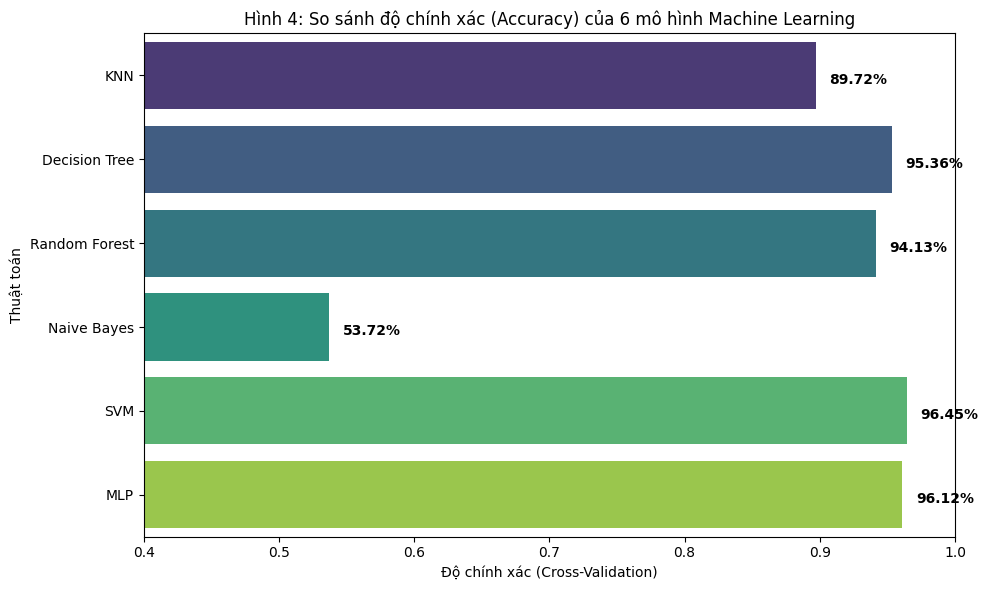


######################################################################
 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - Support Vector Machine (SVM)
######################################################################
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.97      0.98      0.97        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.88      0.92        58
Overweight_Level_II       0.89      0.95      0.92        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



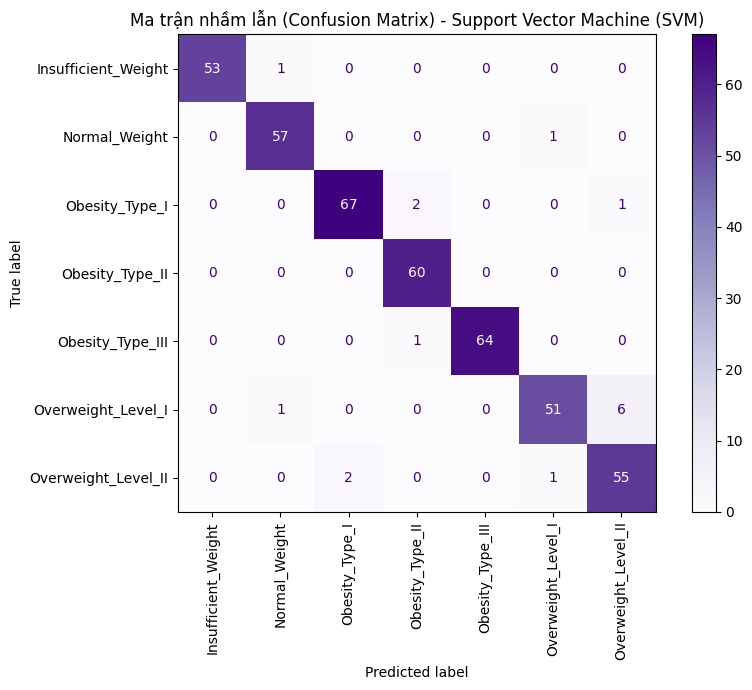


######################################################################
 BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - Neural Network (MLP)
######################################################################
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        54
      Normal_Weight       0.95      0.91      0.93        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.95      0.94        58
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



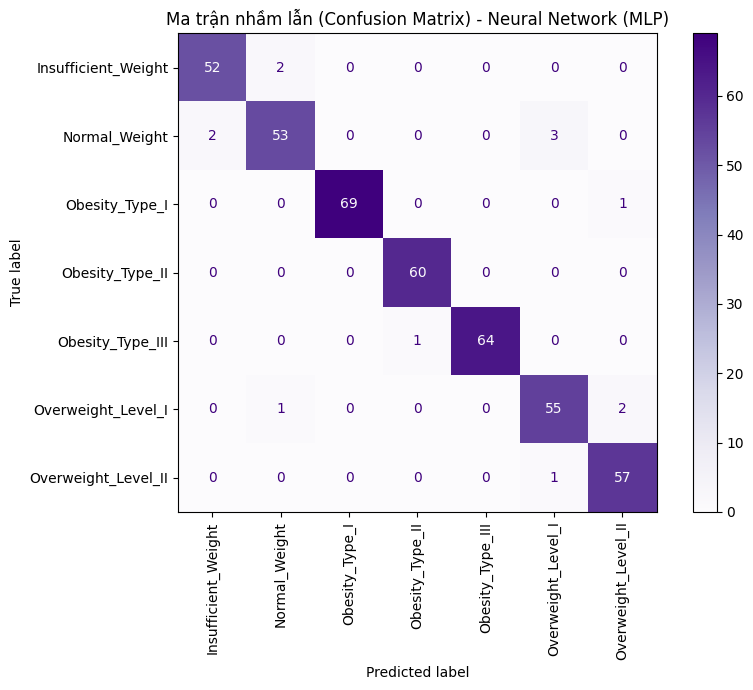


--- Đang vẽ đường cong ROC (ROC Curve) cho mô hình Neural Network (MLP) ---


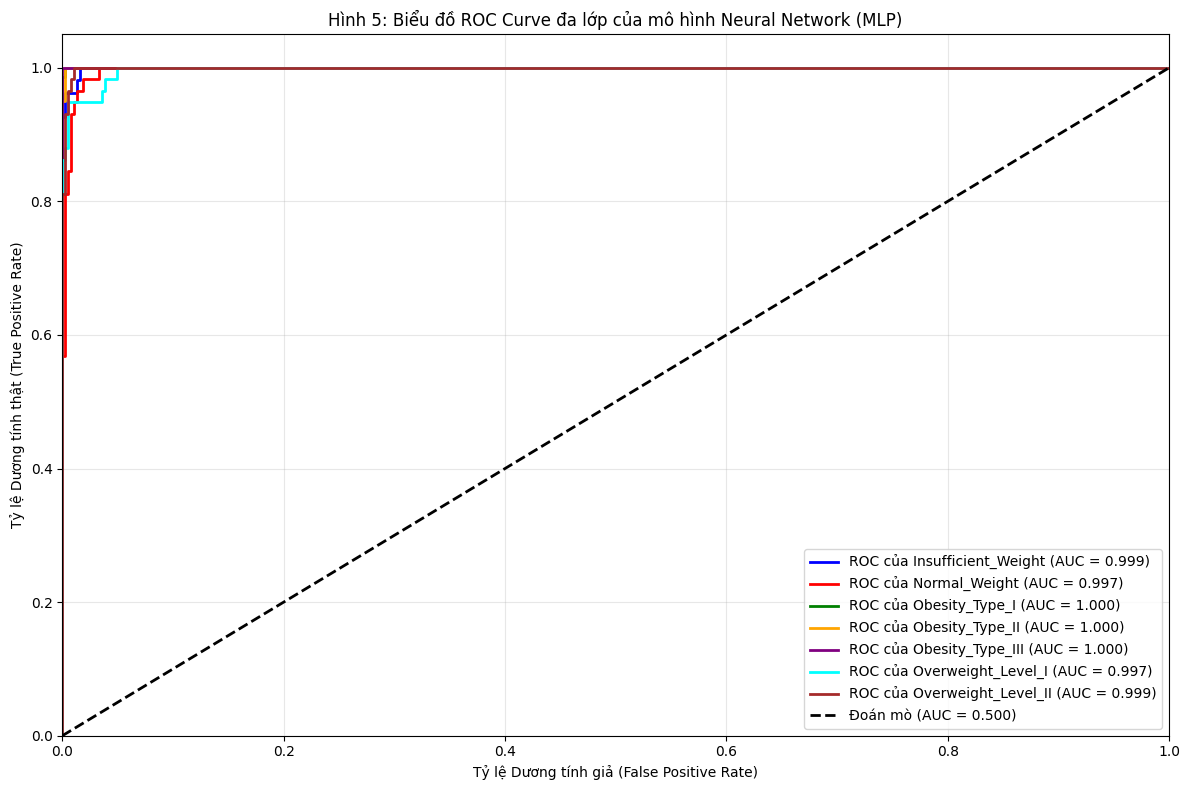

In [6]:
# =========================================================================
# SECTION 5: FINAL COMPARISON & CHUYÊN SÂU REPORT
# =========================================================================
print("\n" + "="*50)
print("--- [Section 5]: TIẾN HÀNH XUẤT ĐỒ THỊ VÀ BÁO CÁO CHI TIẾT ---")
print("="*50)

# 1. BIỂU ĐỒ CỘT SO SÁNH ACCURACY 6 MÔ HÌNH (Lấy điểm tự động từ Grid)
model_names = ['KNN', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM', 'MLP']
accuracies = [knn_grid.best_score_, tree_grid.best_score_, rf_grid.best_score_, nb_grid.best_score_, svm_grid.best_score_, mlp_grid.best_score_]

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracies, y=model_names, hue=model_names, palette='viridis', legend=False)
plt.xlim(0.4, 1.0)
plt.title('Hình 4: So sánh độ chính xác (Accuracy) của 6 mô hình Machine Learning')
plt.xlabel('Độ chính xác (Cross-Validation)')
plt.ylabel('Thuật toán')
for i, v in enumerate(accuracies):
    plt.text(v + 0.01, i + 0.1, f"{v*100:.2f}%", color='black', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. XUẤT CLASSIFICATION REPORT & CONFUSION MATRIX CHO SVM VÀ MLP
# Trích xuất X_test, y_test độc lập giống Phú để vẽ
for train_idx, test_idx in skf.split(X_selected_matrix, y_encoded):
    X_train, X_test = X_selected_matrix[train_idx], X_selected_matrix[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    break

best_models = {
    'Support Vector Machine (SVM)': svm_grid.best_estimator_,
    'Neural Network (MLP)': mlp_grid.best_estimator_
}

for name, model in best_models.items():
    print("\n" + "#"*70)
    print(f" BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) - {name}")
    print("#"*70)
    
    # BƯỚC QUAN TRỌNG NHẤT: Bắt buộc phải fit lại mô hình trên X_train để tránh đánh giá ảo (Data Leakage)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    fig, ax = plt.subplots(figsize=(9, 7))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Purples', xticks_rotation='vertical', ax=ax)
    plt.title(f"Ma trận nhầm lẫn (Confusion Matrix) - {name}")
    plt.tight_layout()
    plt.show()

# 3. VẼ ĐƯỜNG CONG ROC CHO MLP
print("\n--- Đang vẽ đường cong ROC (ROC Curve) cho mô hình Neural Network (MLP) ---")
y_test_bin = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_test_bin.shape[1]

# Lấy mô hình MLP tốt nhất (đã được fit lại trên X_train ở vòng lặp trên)
best_mlp = best_models['Neural Network (MLP)']
y_score = best_mlp.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'brown']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC của {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Đoán mò (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.title('Hình 5: Biểu đồ ROC Curve đa lớp của mô hình Neural Network (MLP)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

--- [Section 5 - Phần bổ sung]: ĐÁNH GIÁ CHUYÊN SÂU THEO YÊU CẦU ---

 BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: Support Vector Machine (SVM)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.97      0.98      0.97        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.88      0.92        58
Overweight_Level_II       0.89      0.95      0.92        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



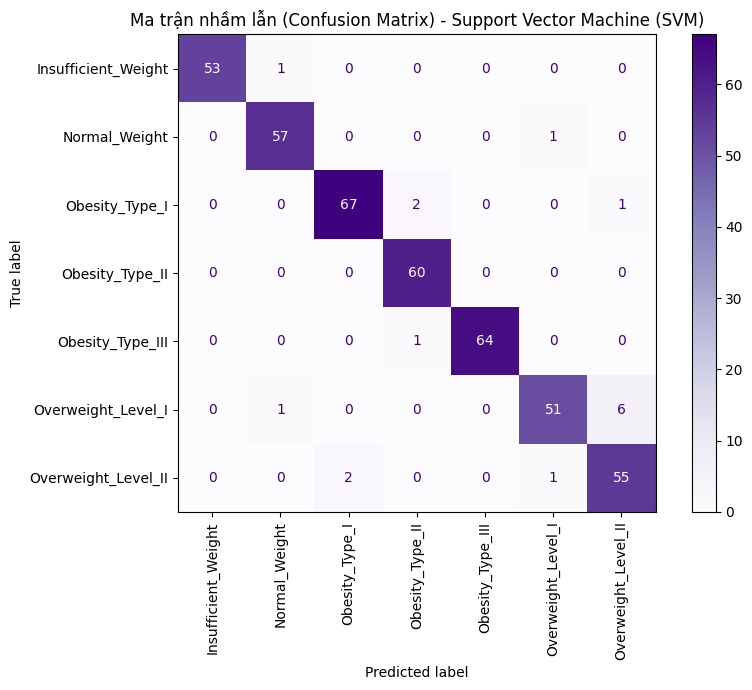


 BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: Neural Network (MLP)
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        54
      Normal_Weight       0.95      0.91      0.93        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.95      0.94        58
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



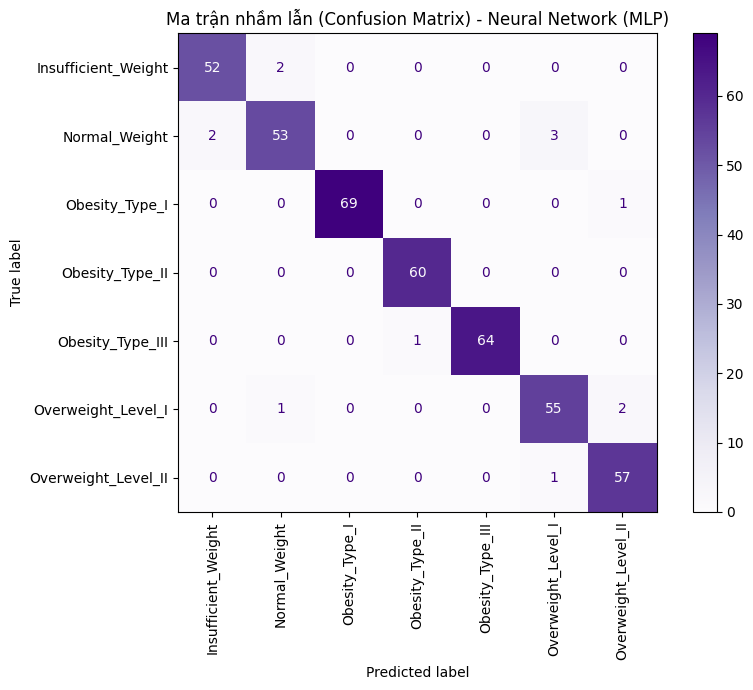


=> ĐÃ XUẤT XONG BẢNG BÁO CÁO CHI TIẾT VÀ CON FUSION MATRIX CHO SVM & MLP!


In [7]:
# =========================================================================
# SECTION 5 (TIẾP THEO): BÁO CÁO CHI TIẾT & MA TRẬN NHẦM LẪN (CLASSIFICATION REPORT)
# Được thực hiện bởi Vũ Thiên Sinh (Đáp ứng góp ý nâng cấp đồ án)
# =========================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("--- [Section 5 - Phần bổ sung]: ĐÁNH GIÁ CHUYÊN SÂU THEO YÊU CẦU ---")

# Lấy 2 mô hình tốt nhất sau khi quét cạn của bạn
best_models = {
    'Support Vector Machine (SVM)': svm_grid.best_estimator_,
    'Neural Network (MLP)': mlp_grid.best_estimator_
}

# Vòng lặp tự động in ra Classification Report và vẽ Confusion Matrix cho từng mô hình
for name, model in best_models.items():
    print("\n" + "="*70)
    print(f" BÁO CÁO CHI TIẾT ĐÁNH GIÁ MÔ HÌNH: {name}")
    print("="*70)
    
    # Dự đoán trên tập X_test đã được Phú chia từ trước
    y_pred = model.predict(X_test)
    
    # 1. In bảng Classification Report (Precision, Recall, F1-Score từng lớp béo phì)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # 2. Vẽ và hiển thị trực quan Ma trận nhầm lẫn (Confusion Matrix)
    fig, ax = plt.subplots(figsize=(9, 7))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap='Purples', xticks_rotation='vertical', ax=ax)
    plt.title(f"Ma trận nhầm lẫn (Confusion Matrix) - {name}")
    plt.tight_layout()
    plt.show()

print("\n=> ĐÃ XUẤT XONG BẢNG BÁO CÁO CHI TIẾT VÀ CON FUSION MATRIX CHO SVM & MLP!")